Starting to fetch data...
Progress: 0.21% complete
Progress: 0.41% complete
Progress: 0.62% complete
Progress: 0.83% complete
Progress: 1.03% complete
Progress: 1.24% complete
Progress: 1.45% complete
Progress: 1.65% complete
Progress: 1.86% complete
Progress: 2.07% complete
Progress: 2.27% complete
Progress: 2.48% complete
Progress: 2.69% complete
Progress: 2.89% complete
Progress: 3.10% complete
Progress: 3.31% complete
Progress: 3.51% complete
Progress: 3.72% complete
Progress: 3.93% complete
Progress: 4.13% complete
Progress: 4.34% complete
Progress: 4.55% complete
Progress: 4.75% complete
Progress: 4.96% complete
Progress: 5.17% complete
Progress: 5.37% complete
Progress: 5.58% complete
Progress: 5.79% complete
Progress: 5.99% complete
Progress: 6.20% complete
Progress: 6.40% complete
Progress: 6.61% complete
Progress: 6.82% complete
Progress: 7.02% complete
Progress: 7.23% complete
Progress: 7.44% complete
Progress: 7.64% complete
Progress: 7.85% complete
Progress: 8.06% complete

C:\Users\admin\AppData\Local\Temp\ipykernel_16812\593765773.py:49: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


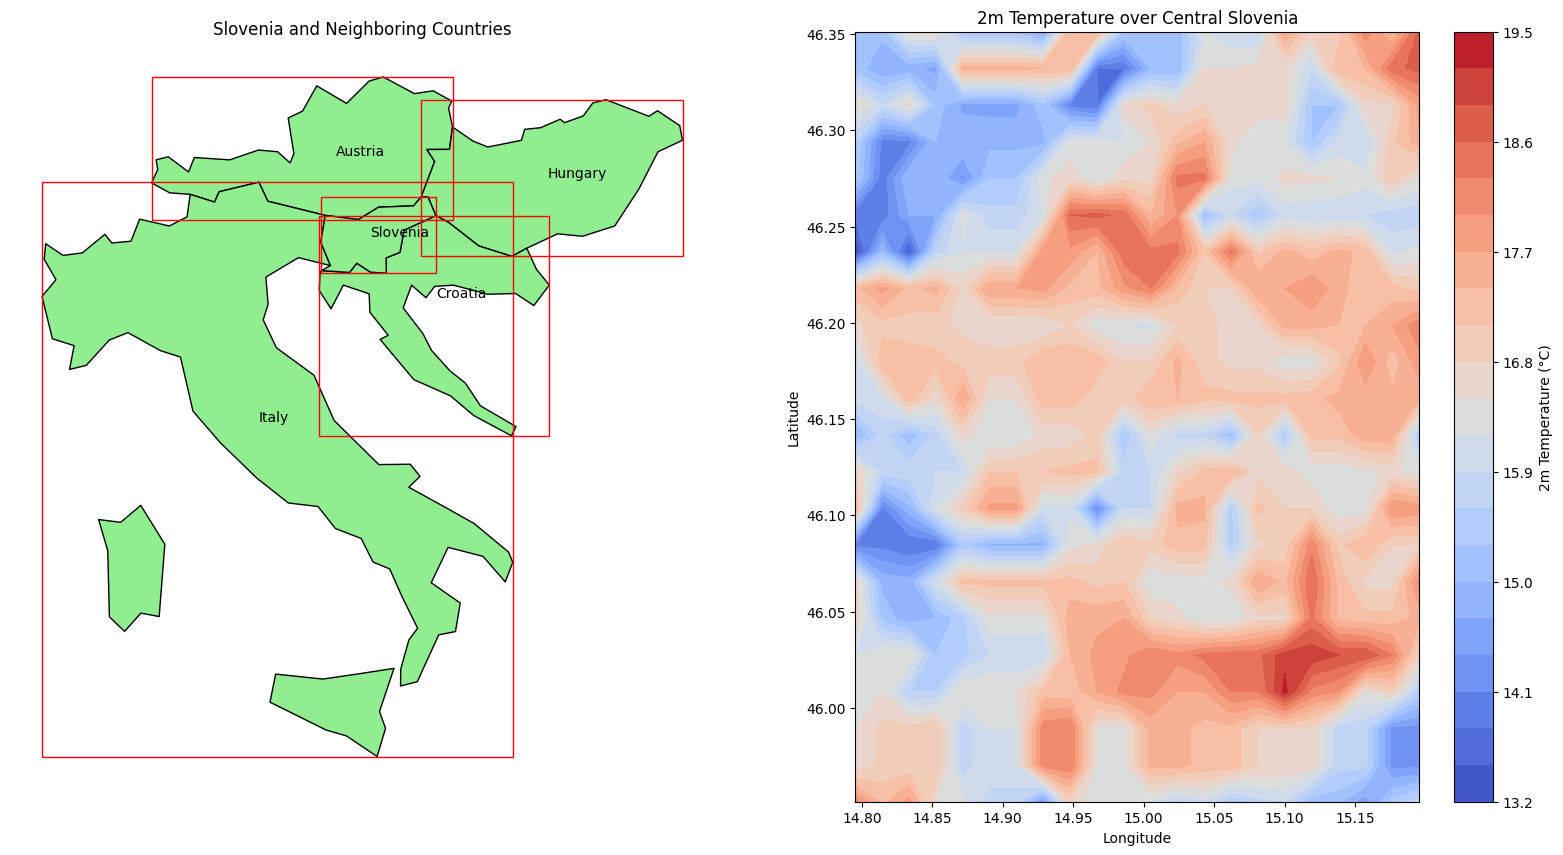

In [1]:
import geopandas as gpd
import requests
import numpy as np
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv
load_dotenv()

base_url = os.getenv("BASE_URL")

# Define the central coordinates for Slovenia
latitude_center, longitude_center = 46.1512, 14.9955

# Define a bounding box around the center with approximately 2 km resolution
lat_min = latitude_center - 0.2
lat_max = latitude_center + 0.2
lon_min = longitude_center - 0.2
lon_max = longitude_center + 0.2

# Grid for latitude and longitude with approximately 2 km resolution
lat_values = np.linspace(lat_min, lat_max, int((lat_max - lat_min) / 0.018))
lon_values = np.linspace(lon_min, lon_max, int((lon_max - lon_min) / 0.018))

temperature_2m = []

# Print a starting message
print("Starting to fetch data...")

# Loop through the grid and fetch the temperature values
for i, lat in enumerate(lat_values):
    for j, lon in enumerate(lon_values):
        # Build the API URL
        url = f"https://{base_url}/v1/dwd-icon?latitude={lat}&longitude={lon}&hourly=temperature_2m"
        
        # Fetch data
        response = requests.get(url)
        data = response.json()

        # Extract 2m temperature
        temp = data['hourly']['temperature_2m'][0]
        temperature_2m.append(temp)

        # Print progress update
        progress_percentage = (i * len(lon_values) + j + 1) / (len(lat_values) * len(lon_values)) * 100
        print(f"Progress: {progress_percentage:.2f}% complete")

# Print completion message
print("Data fetching complete.")

# Reshape the temperature data to match the grid shape
temperature_2m = np.reshape(temperature_2m, (len(lat_values), len(lon_values)))

# Load the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
countries = ['Slovenia', 'Austria', 'Italy', 'Hungary', 'Croatia']
region = world[world['name'].isin(countries)]

# Plot the bounding areas
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
ax1 = region.plot(ax=axes[0], color='lightgreen', edgecolor='k')
for idx, row in region.iterrows():
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax1.text(x, y, row['name'], fontsize=10)
    bounds = row['geometry'].bounds
    ax1.add_patch(plt.Rectangle((bounds[0], bounds[1]), bounds[2] - bounds[0], bounds[3] - bounds[1], fill=False, edgecolor='red'))
axes[0].set_title("Slovenia and Neighboring Countries")
axes[0].axis('off')

# Plot the 2m temperature
lon_values_map, lat_values_map = np.meshgrid(lon_values, lat_values)
cp = axes[1].contourf(lon_values_map, lat_values_map, temperature_2m, 20, cmap='coolwarm')
plt.colorbar(cp, label="2m Temperature (°C)", ax=axes[1])
axes[1].set_title("2m Temperature over Central Slovenia")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.show()
